In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
df = pd.read_csv('/rolling_stones_spotify.csv')

In [ ]:
print(df)

      Unnamed: 0                         name               album  \
0              0   Concert Intro Music - Live  Licked Live In NYC   
1              1   Street Fighting Man - Live  Licked Live In NYC   
2              2           Start Me Up - Live  Licked Live In NYC   
3              3  If You Can't Rock Me - Live  Licked Live In NYC   
4              4            Don’t Stop - Live  Licked Live In NYC   
...          ...                          ...                 ...   
1605        1605                        Carol  The Rolling Stones   
1606        1606                      Tell Me  The Rolling Stones   
1607        1607          Can I Get A Witness  The Rolling Stones   
1608        1608   You Can Make It If You Try  The Rolling Stones   
1609        1609              Walking The Dog  The Rolling Stones   

     release_date  track_number                      id  \
0      2022-06-10             1  2IEkywLJ4ykbhi1yRQvmsT   
1      2022-06-10             2  6GVgVJBKkGJoRfarYRvG

In [ ]:
df.shape


(1610, 18)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1610 entries, 0 to 1609
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        1610 non-null   int64  
 1   name              1610 non-null   object 
 2   album             1610 non-null   object 
 3   release_date      1610 non-null   object 
 4   track_number      1610 non-null   int64  
 5   id                1610 non-null   object 
 6   uri               1610 non-null   object 
 7   acousticness      1610 non-null   float64
 8   danceability      1610 non-null   float64
 9   energy            1610 non-null   float64
 10  instrumentalness  1610 non-null   float64
 11  liveness          1610 non-null   float64
 12  loudness          1610 non-null   float64
 13  speechiness       1610 non-null   float64
 14  tempo             1610 non-null   float64
 15  valence           1610 non-null   float64
 16  popularity        1610 non-null   int64  


In [ ]:
df.describe()

,Unnamed: 0,track_number,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms
count,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.00000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000
mean,804.500000,8.613665,0.250475,0.468860,0.792352,0.164170,0.49173,-6.971615,0.069512,126.082033,0.582165,20.788199,257736.488199
std,464.911282,6.560220,0.227397,0.141775,0.179886,0.276249,0.34910,2.994003,0.051631,29.233483,0.231253,12.426859,108333.474920
min,0.000000,1.000000,0.000009,0.104000,0.141000,0.000000,0.02190,-24.408000,0.023200,46.525000,0.000000,0.000000,21000.000000
25%,402.250000,4.000000,0.058350,0.362250,0.674000,0.000219,0.15300,-8.982500,0.036500,107.390750,0.404250,13.000000,190613.000000
50%,804.500000,7.000000,0.183000,0.458000,0.848500,0.013750,0.37950,-6.523000,0.051200,124.404500,0.583000,20.000000,243093.000000
75%,1206.750000,11.000000,0.403750,0.578000,0.945000,0.179000,0.89375,-4.608750,0.086600,142.355750,0.778000,27.000000,295319.750000
max,1609.000000,47.000000,0.994000,0.887000,0.999000,0.996000,0.99800,-1.014000,0.624000,216.304000,0.974000,80.000000,981866.000000


In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
name,0
album,0
release_date,0
track_number,0
id,0
uri,0
acousticness,0
danceability,0
energy,0


In [ ]:
df.columns

Index(['Unnamed: 0', 'name', 'album', 'release_date', 'track_number', 'id',
       'uri', 'acousticness', 'danceability', 'energy', 'instrumentalness',
       'liveness', 'loudness', 'speechiness', 'tempo', 'valence', 'popularity',
       'duration_ms'],
      dtype='object')

In [ ]:
df.dtypes

,0
Unnamed: 0,int64
name,object
album,object
release_date,object
track_number,int64
id,object
uri,object
acousticness,float64
danceability,float64
energy,float64


In [ ]:
df


,Unnamed: 0,name,album,release_date,track_number,id,uri,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms
0,0,Concert Intro Music - Live,Licked Live In NYC,2022-06-10,1,2IEkywLJ4ykbhi1yRQvmsT,spotify:track:2IEkywLJ4ykbhi1yRQvmsT,0.0824,0.463,0.993,0.996000,0.9320,-12.913,0.1100,118.001,0.0302,33,48640
1,1,Street Fighting Man - Live,Licked Live In NYC,2022-06-10,2,6GVgVJBKkGJoRfarYRvGTU,spotify:track:6GVgVJBKkGJoRfarYRvGTU,0.4370,0.326,0.965,0.233000,0.9610,-4.803,0.0759,131.455,0.3180,34,253173
2,2,Start Me Up - Live,Licked Live In NYC,2022-06-10,3,1Lu761pZ0dBTGpzxaQoZNW,spotify:track:1Lu761pZ0dBTGpzxaQoZNW,0.4160,0.386,0.969,0.400000,0.9560,-4.936,0.1150,130.066,0.3130,34,263160
3,3,If You Can't Rock Me - Live,Licked Live In NYC,2022-06-10,4,1agTQzOTUnGNggyckEqiDH,spotify:track:1agTQzOTUnGNggyckEqiDH,0.5670,0.369,0.985,0.000107,0.8950,-5.535,0.1930,132.994,0.1470,32,305880
4,4,Don’t Stop - Live,Licked Live In NYC,2022-06-10,5,7piGJR8YndQBQWVXv6KtQw,spotify:track:7piGJR8YndQBQWVXv6KtQw,0.4000,0.303,0.969,0.055900,0.9660,-5.098,0.0930,130.533,0.2060,32,305106
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1605,1605,Carol,The Rolling Stones,1964-04-16,8,08l7M5UpRnffGl0FyuRiQZ,spotify:track:08l7M5UpRnffGl0FyuRiQZ,0.1570,0.466,0.932,0.006170,0.3240,-9.214,0.0429,177.340,0.9670,39,154080
1606,1606,Tell Me,The Rolling Stones,1964-04-16,9,3JZllQBsTM6WwoJdzFDLhx,spotify:track:3JZllQBsTM6WwoJdzFDLhx,0.0576,0.509,0.706,0.000002,0.5160,-9.427,0.0843,122.015,0.4460,36,245266
1607,1607,Can I Get A Witness,The Rolling Stones,1964-04-16,10,0t2qvfSBQ3Y08lzRRoVTdb,spotify:track:0t2qvfSBQ3Y08lzRRoVTdb,0.3710,0.790,0.774,0.000000,0.0669,-7.961,0.0720,97.035,0.8350,30,176080
1608,1608,You Can Make It If You Try,The Rolling Stones,1964-04-16,11,5ivIs5vwSj0RChOIvlY3On,spotify:track:5ivIs5vwSj0RChOIvlY3On,0.2170,0.700,0.546,0.000070,0.1660,-9.567,0.0622,102.634,0.5320,27,121680


In [ ]:
import pandas as pd

# sample DataFrame with numeric data
data = {'name': ['WB','WS','AS','DS','CD'],
        'album': ['A','B','C','D','E'],
        'release_date': ['10/10/2000', '28/10/2000', '15/08/1990','14/10/2000','12/10/2000'],
        'track_num': [1,2,3,4,5]
        }

df = pd.DataFrame(data)

# compute correlation matrix


In [ ]:
print(df)

  name album release_date  track_num
0   WB     A   10/10/2000          1
1   WS     B   28/10/2000          2
2   AS     C   15/08/1990          3
3   DS     D   14/10/2000          4
4   CD     E   12/10/2000          5


In [ ]:
correlation_matrix = df.corr(numeric_only=True)

print(correlation_matrix)

           track_num
track_num        1.0


<Axes: >

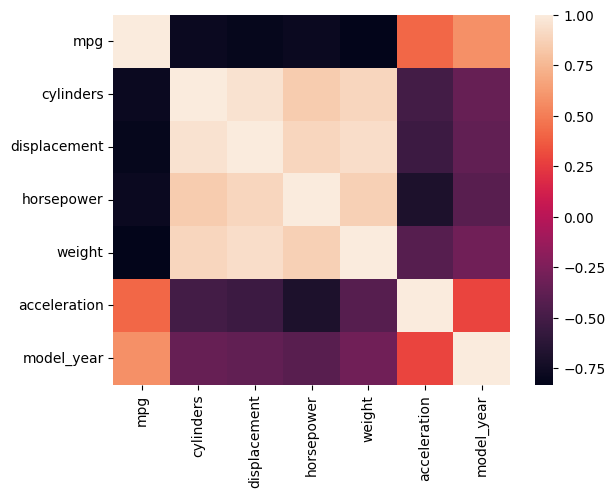

In [ ]:
auto_df = sns.load_dataset('mpg')
corr = auto_df.select_dtypes('number').corr()
sns.heatmap(corr)



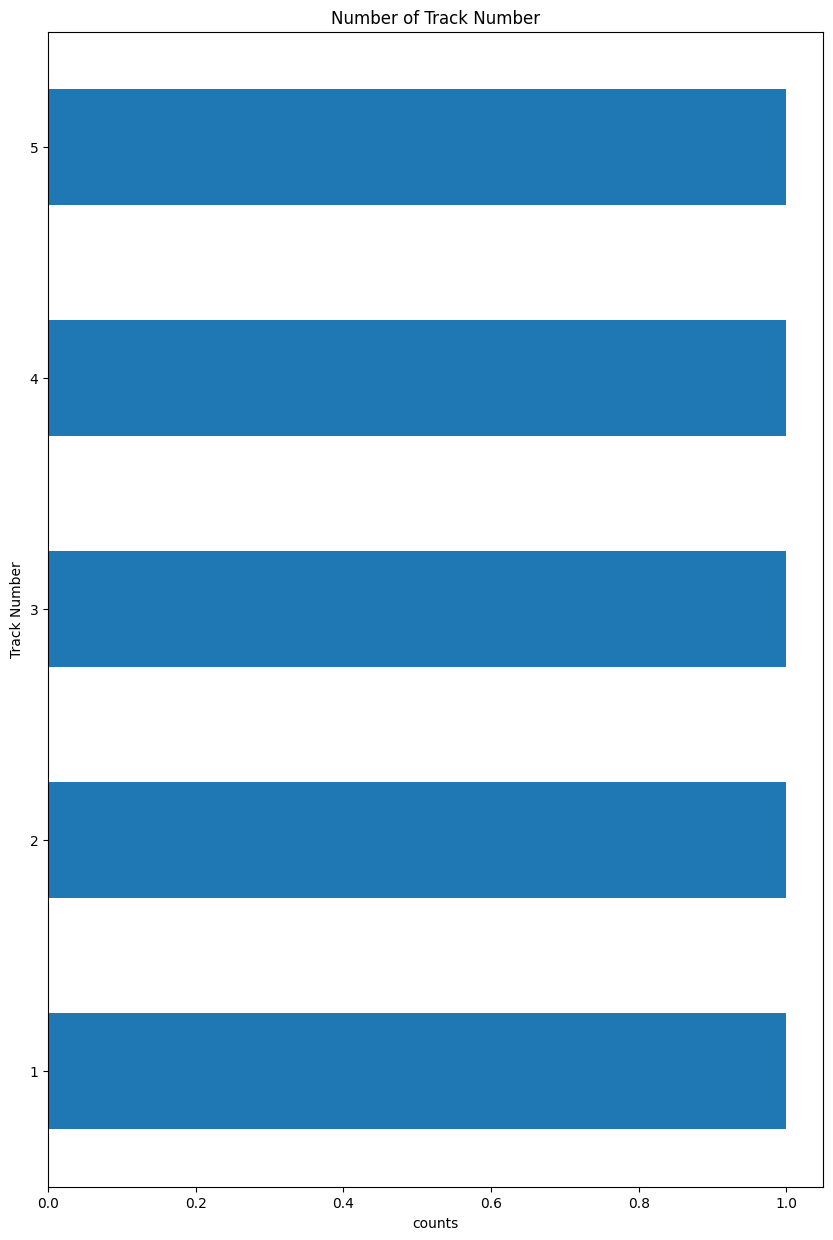

In [ ]:
df['track_num'].value_counts().plot(kind='barh', figsize=(10,15))
plt.xlabel('counts')
plt.ylabel('Track Number')
plt.title('Number of Track Number')
plt.show()


NameError: name 'tips' is not defined

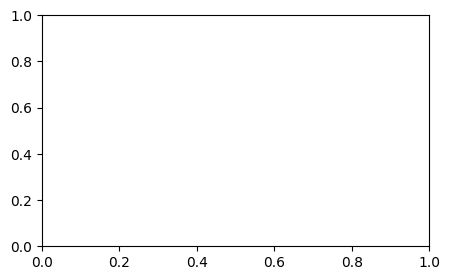

In [ ]:
fig, ax = plt.subplots(figsize = ( 5 , 3 ))

sns.scatterplot( ax = df , x = "acousticness" , y = "energy" , data = tips )

df.set_xlabel( "acousticness" )

# Set label for y-axis
df.set_ylabel( "energy" )

# Set title for plot
df.set_title( "acousticness vs energy" , size = 24 )

# Display figure
plt.show()

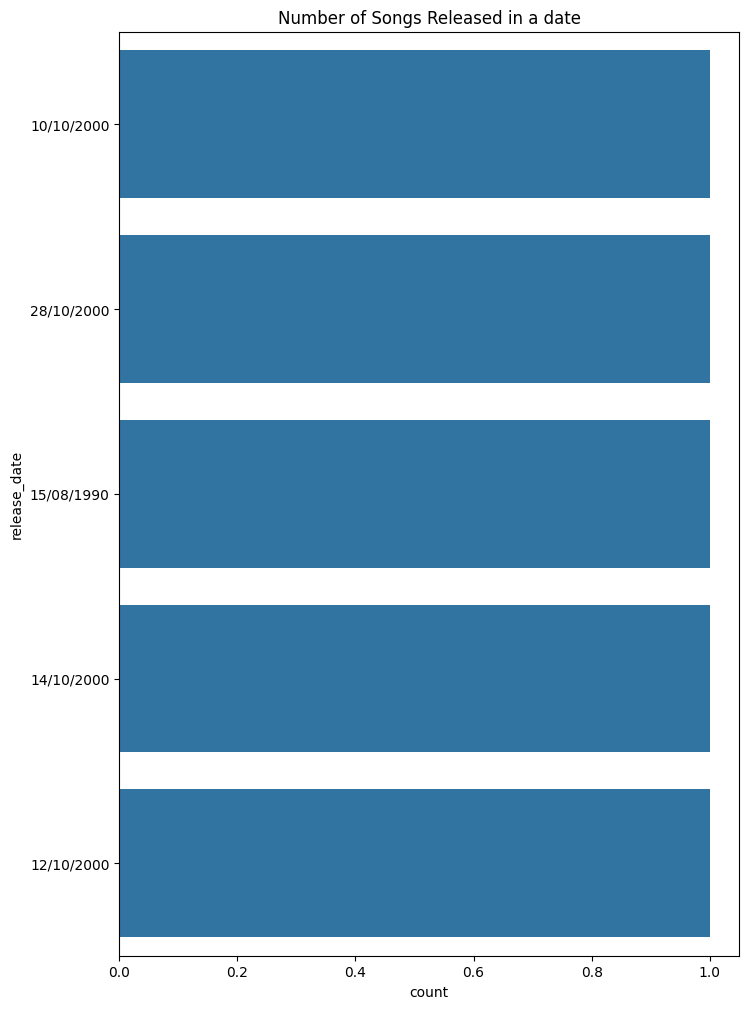

In [ ]:
plt.figure(figsize=(8,12))
sns.countplot(y=df['release_date'])
plt.title('Number of Songs Released in a date')
plt.show()

   track_number  popularity  energy  danceability  liveness  loudness
0             1          32   0.993         0.236     0.110     0.231
1             2          33   0.565         0.342     0.230     0.124
2             3          34   0.455         0.450     0.324     0.321
3             4          45   0.383         0.500     0.434     0.423
4             5          22   0.450         0.650     0.523     0.541


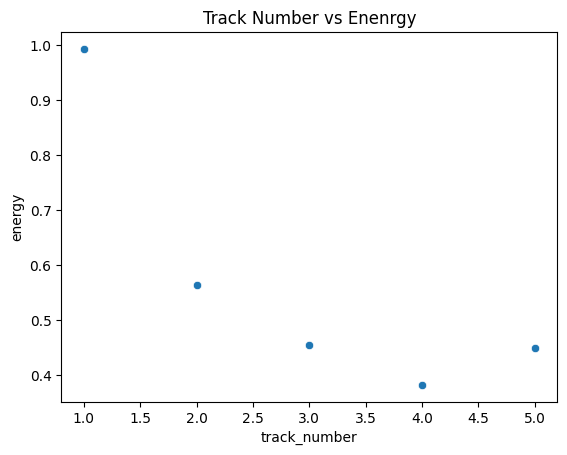

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

data={

      'track_number': [1,2,3,4,5],
      'popularity': [32,33,34,45,22],
      'energy': [0.993,0.565,0.455,0.383,0.450],
      'danceability':[0.236,0.342,0.450,0.500,0.650],
      'liveness': [0.110,0.230,0.324,0.434,0.523],
      'loudness': [0.231,0.124,0.321,0.423,0.541]
  }



df=pd.DataFrame(data)
print(df)

sns.scatterplot(x=df['track_number'],y=df['energy'])
plt.title('Track Number vs Enenrgy')
plt.show()

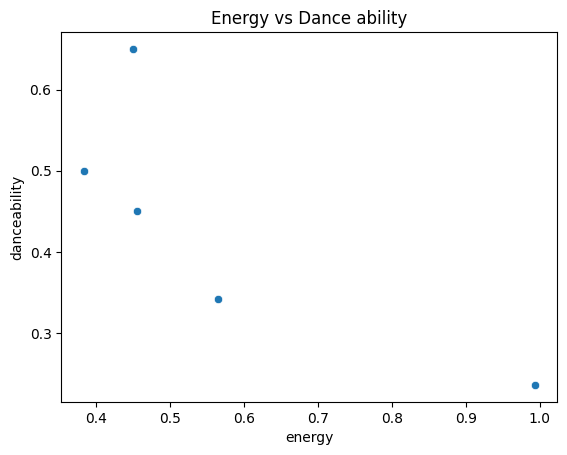

In [ ]:
sns.scatterplot(x=df['energy'],y=df['danceability'])
plt.title('Energy vs Dance ability')
plt.show()

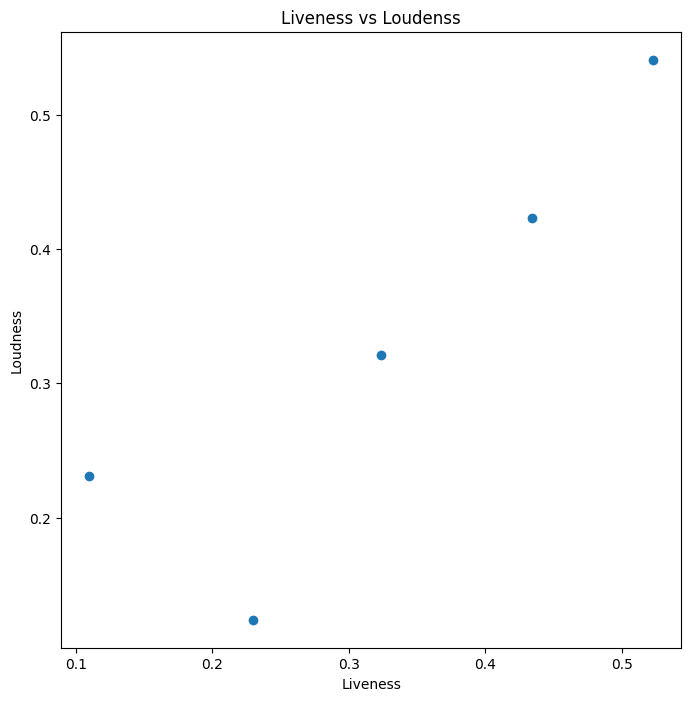

In [ ]:
plt.figure(figsize=(8,8),dpi=100)
plt.scatter(x=df['liveness'],y=df['loudness'])
plt.xlabel('Liveness')
plt.ylabel('Loudness')
plt.title('Liveness vs Loudenss')
plt.show()

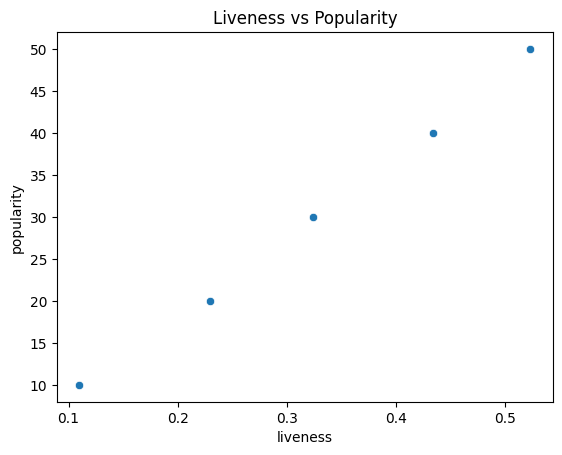

In [ ]:
sns.scatterplot(x=df['liveness'],y=df['popularity'])
plt.title('Liveness vs Popularity')
plt.show()

In [ ]:
df


,track_number,energy,danceability,liveness,loudness,popularity
0,1,0.993,0.236,0.110,0.231,10
1,2,0.565,0.342,0.230,0.124,20
2,3,0.455,0.450,0.324,0.321,30
3,4,0.383,0.500,0.434,0.423,40
4,5,0.450,0.650,0.523,0.541,50


In [ ]:
df.dtypes

,0
track_number,int64
energy,float64
danceability,float64
liveness,float64
loudness,float64
popularity,int64


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

data={

    'name': ['abc','def','xyz','fre','ght'],
      'release_date': [10/12/96,12/4/98,13/7/94,2/4/98,8/12/24],
       'id': [1000,2000,3000,4000,5000],
               'url': ['spotify:track:test','spotify:track:test1','spotify:track:test2','spotify:track:test3','spotify:track:test4']
}
df=pd.DataFrame(data)
print(df)


columns_to_drop = [2, 3]  # Index positions of 'Profession' and 'Favorite_Coffee'
df_dropped_indices = df.drop(df.columns[columns_to_drop], axis=1)

print("\nDataset after dropping columns by index positions:")
display(df_dropped_indices)

  name  release_date    id                  url
0  abc      0.008681  1000   spotify:track:test
1  def      0.030612  2000  spotify:track:test1
2  xyz      0.019757  3000  spotify:track:test2
3  fre      0.005102  4000  spotify:track:test3
4  ght      0.027778  5000  spotify:track:test4

Dataset after dropping columns by index positions:


,name,release_date
0,abc,0.008681
1,def,0.030612
2,xyz,0.019757
3,fre,0.005102
4,ght,0.027778


In [ ]:
df

,name,release_date,id,url
0,abc,0.008681,1000,spotify:track:test
1,def,0.030612,2000,spotify:track:test1
2,xyz,0.019757,3000,spotify:track:test2
3,fre,0.005102,4000,spotify:track:test3
4,ght,0.027778,5000,spotify:track:test4


In [ ]:
y = df['name']

In [ ]:
y

,name
0,abc
1,def
2,xyz
3,fre
4,ght


In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
le = LabelEncoder()

In [ ]:
from re import X
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


data={

    'name': ['abc','def','xyz','fre','ght'],
    'album': [0,1,2,3,4],
      'release_date': [10/12/96,12/4/98,13/7/94,2/4/98,8/12/24],
       'id': [1000,2000,3000,4000,5000],
               'url': ['spotify:track:test','spotify:track:test1','spotify:track:test2','spotify:track:test3','spotify:track:test4']
}
df=pd.DataFrame(data)
print(df)

# Initializing LabelEncoder
le = LabelEncoder()

# Applying LabelEncoder on categorical columns
df['name'] = le.fit_transform(df['name'])
df['album'] = le.fit_transform(df['album'])

# Displaying the DataFrame after label encoding
print("\nDataFrame after Label Encoding:")
print(df)

  name  album  release_date    id                  url
0  abc      0      0.008681  1000   spotify:track:test
1  def      1      0.030612  2000  spotify:track:test1
2  xyz      2      0.019757  3000  spotify:track:test2
3  fre      3      0.005102  4000  spotify:track:test3
4  ght      4      0.027778  5000  spotify:track:test4

DataFrame after Label Encoding:
   name  album  release_date    id                  url
0     0      0      0.008681  1000   spotify:track:test
1     1      1      0.030612  2000  spotify:track:test1
2     4      2      0.019757  3000  spotify:track:test2
3     2      3      0.005102  4000  spotify:track:test3
4     3      4      0.027778  5000  spotify:track:test4


In [ ]:
df.head()

,name,album,release_date,id,url
0,0,0,0.008681,1000,spotify:track:test
1,1,1,0.030612,2000,spotify:track:test1
2,4,2,0.019757,3000,spotify:track:test2
3,2,3,0.005102,4000,spotify:track:test3
4,3,4,0.027778,5000,spotify:track:test4


In [ ]:
from sklearn.preprocessing import MinMaxScaler

In [ ]:
ms = MinMaxScaler()

In [ ]:
cols = df.columns

In [21]:
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

# create dataset
X, y = make_blobs(n_samples=1000)
# split into train test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)





(670, 2) (330, 2) (670,) (330,)


In [24]:
X

array([[-5.40978797, -4.68130327],
       [ 0.40071223, -3.07226522],
       [-9.0054721 ,  5.65247181],
       ...,
       [-6.2297101 , -3.36598471],
       [-9.23190276,  5.99009267],
       [-0.71066775, -3.4060851 ]])

In [25]:
from sklearn.cluster import KMeans

In [26]:
cs = []
for i in range(1,10):
    kmeans = KMeans(n_clusters=i,init='k-means++',max_iter=300,n_init=10,random_state=0)
    kmeans.fit(X)
    cs.append(kmeans.inertia_)

In [28]:
from sklearn.cluster import KMeans
from sklearn import metrics
from scipy.spatial.distance import cdist
import numpy as np
import matplotlib.pyplot as plt

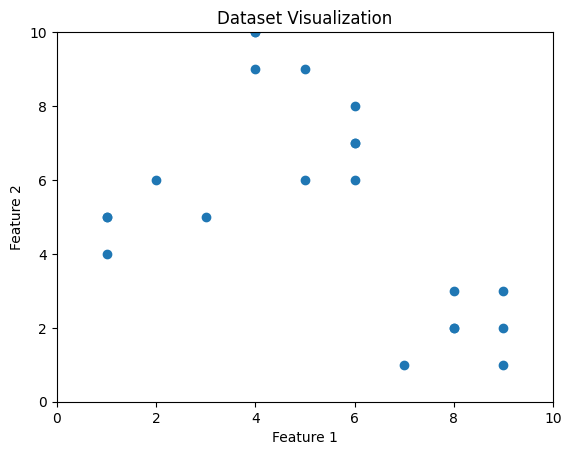

In [31]:
x1 = np.array([3, 1, 1, 2, 1, 6, 6, 6, 5, 6,
               7, 8, 9, 8, 9, 9, 8, 4, 4, 5, 4])
x2 = np.array([5, 4, 5, 6, 5, 8, 6, 7, 6, 7,
               1, 2, 1, 2, 3, 2, 3, 9, 10, 9, 10])
X = np.array(list(zip(x1, x2))).reshape(len(x1), 2)

# Visualizing the data
plt.scatter(x1, x2, marker='o')
plt.xlim([0, 10])
plt.ylim([0, 10])

plt.title('Dataset Visualization')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

In [32]:
kmeans = KMeans(n_clusters=2,random_state=0)

In [33]:
kmeans.fit(X)

KMeans(n_clusters=2, random_state=0)

In [34]:
labels = kmeans.labels_

In [37]:
kmeans.cluster_centers_

array([[8.28571429, 2.        ],
       [3.85714286, 6.92857143]])

In [21]:
from sklearn.cluster import KMeans
from sklearn import metrics
from scipy.spatial.distance import cdist
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

data={
'x': [4, 5, 10, 4, 3, 11, 14 , 6, 10, 12],
'y': [21, 19, 24, 17, 16, 25, 24, 22, 21, 21]  }

df=pd.DataFrame(data)
print(df)

kmeans = KMeans(n_clusters=3, random_state=0)
kmeans.fit(df)

data = list(zip(x, y))
print(data)



    x   y
0   4  21
1   5  19
2  10  24
3   4  17
4   3  16
5  11  25
6  14  24
7   6  22
8  10  21
9  12  21
[(4, 21), (5, 19), (10, 24), (4, 17), (3, 16), (11, 25), (14, 24), (6, 22), (10, 21), (12, 21)]


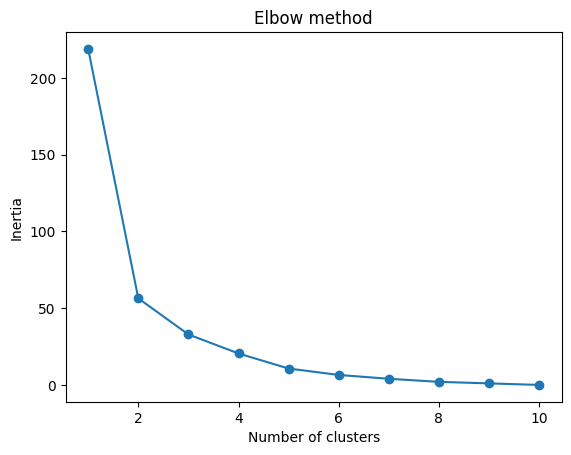

In [22]:
inertias = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(data)
    inertias.append(kmeans.inertia_)

plt.plot(range(1,11), inertias, marker='o')
plt.title('Elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

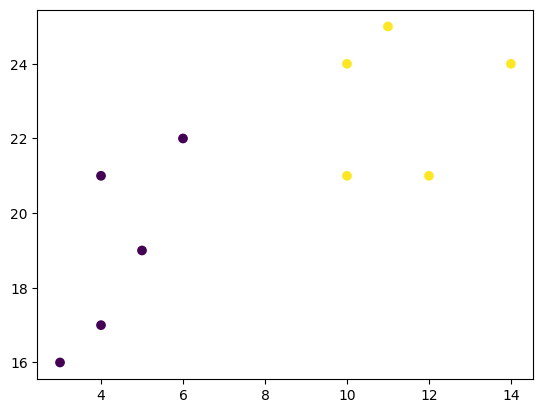

In [23]:
kmeans = KMeans(n_clusters=2)
kmeans.fit(data)

plt.scatter(x, y, c=kmeans.labels_)
plt.show()